In [3]:
import bilby
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [4]:
posterior_NRSur7dq4 = bilby.result.Result.from_json(
    '/holohome/jannik.mielke/subdom_asym/PE/bilby_asym/run4/NRSur/outdir/final_result/NRSur_data0_10-0_analysis_ET_result.json'
)

# posterior_NRSur7dq4_sanity = bilby.result.Result.from_json(
#     '/holohome/jannik.mielke/subdom_asym/PE/bilby_asym/run4/sanity/outdir/final_result/sanity_data0_10-0_analysis_ET_result.json'
# )

posterior_NRSur7dq4_dom_off = bilby.result.Result.from_json(
    '/holohome/jannik.mielke/subdom_asym/PE/bilby_asym/run4/dom_off/outdir/final_result/dom_off_data0_10-0_analysis_ET_result.json'
)

posterior_NRSur7dq4_subdom_off = bilby.result.Result.from_json(
    '/holohome/jannik.mielke/subdom_asym/PE/bilby_asym/run4/subdom_off/outdir/final_result/subdom_off_data0_10-0_analysis_ET_result.json'
)

In [5]:
truths = posterior_NRSur7dq4.injection_parameters

truths

{'total_mass': 90.0,
 'mass_ratio': 1.0,
 'a_1': 0.8,
 'a_2': 0.8,
 'tilt_1': 1.5707963267948966,
 'tilt_2': 1.5707963267948966,
 'phi_12': 3.141592653589793,
 'phi_jl': 0.0,
 'luminosity_distance': 500.0,
 'dec': 0.761,
 'ra': 1.94,
 'theta_jn': 0.0,
 'psi': 0.0,
 'phase': 0.0,
 'geocent_time': 10.0,
 'reference_frequency': 20.0,
 'waveform_approximant': 'NRSur7dq4',
 'minimum_frequency': 20,
 'mass_1': 45.0,
 'mass_2': 45.0,
 'chirp_mass': 39.17477534832557,
 'symmetric_mass_ratio': 0.25,
 'iota': array(0.),
 'spin_1x': array(-0.8),
 'spin_1y': array(-9.79717439e-17),
 'spin_1z': array(4.8985872e-17),
 'spin_2x': array(0.8),
 'spin_2y': array(0.),
 'spin_2z': array(4.8985872e-17),
 'phi_1': 3.141592653589793,
 'phi_2': 0.0,
 'chi_eff': 4.898587196589413e-17,
 'chi_1_in_plane': 0.8,
 'chi_2_in_plane': 0.8,
 'chi_p': 0.8,
 'cos_tilt_1': 6.123233995736766e-17,
 'cos_tilt_2': 6.123233995736766e-17,
 'redshift': 0.10485144638260473,
 'comoving_distance': 452.5495285087919,
 'mass_1_source

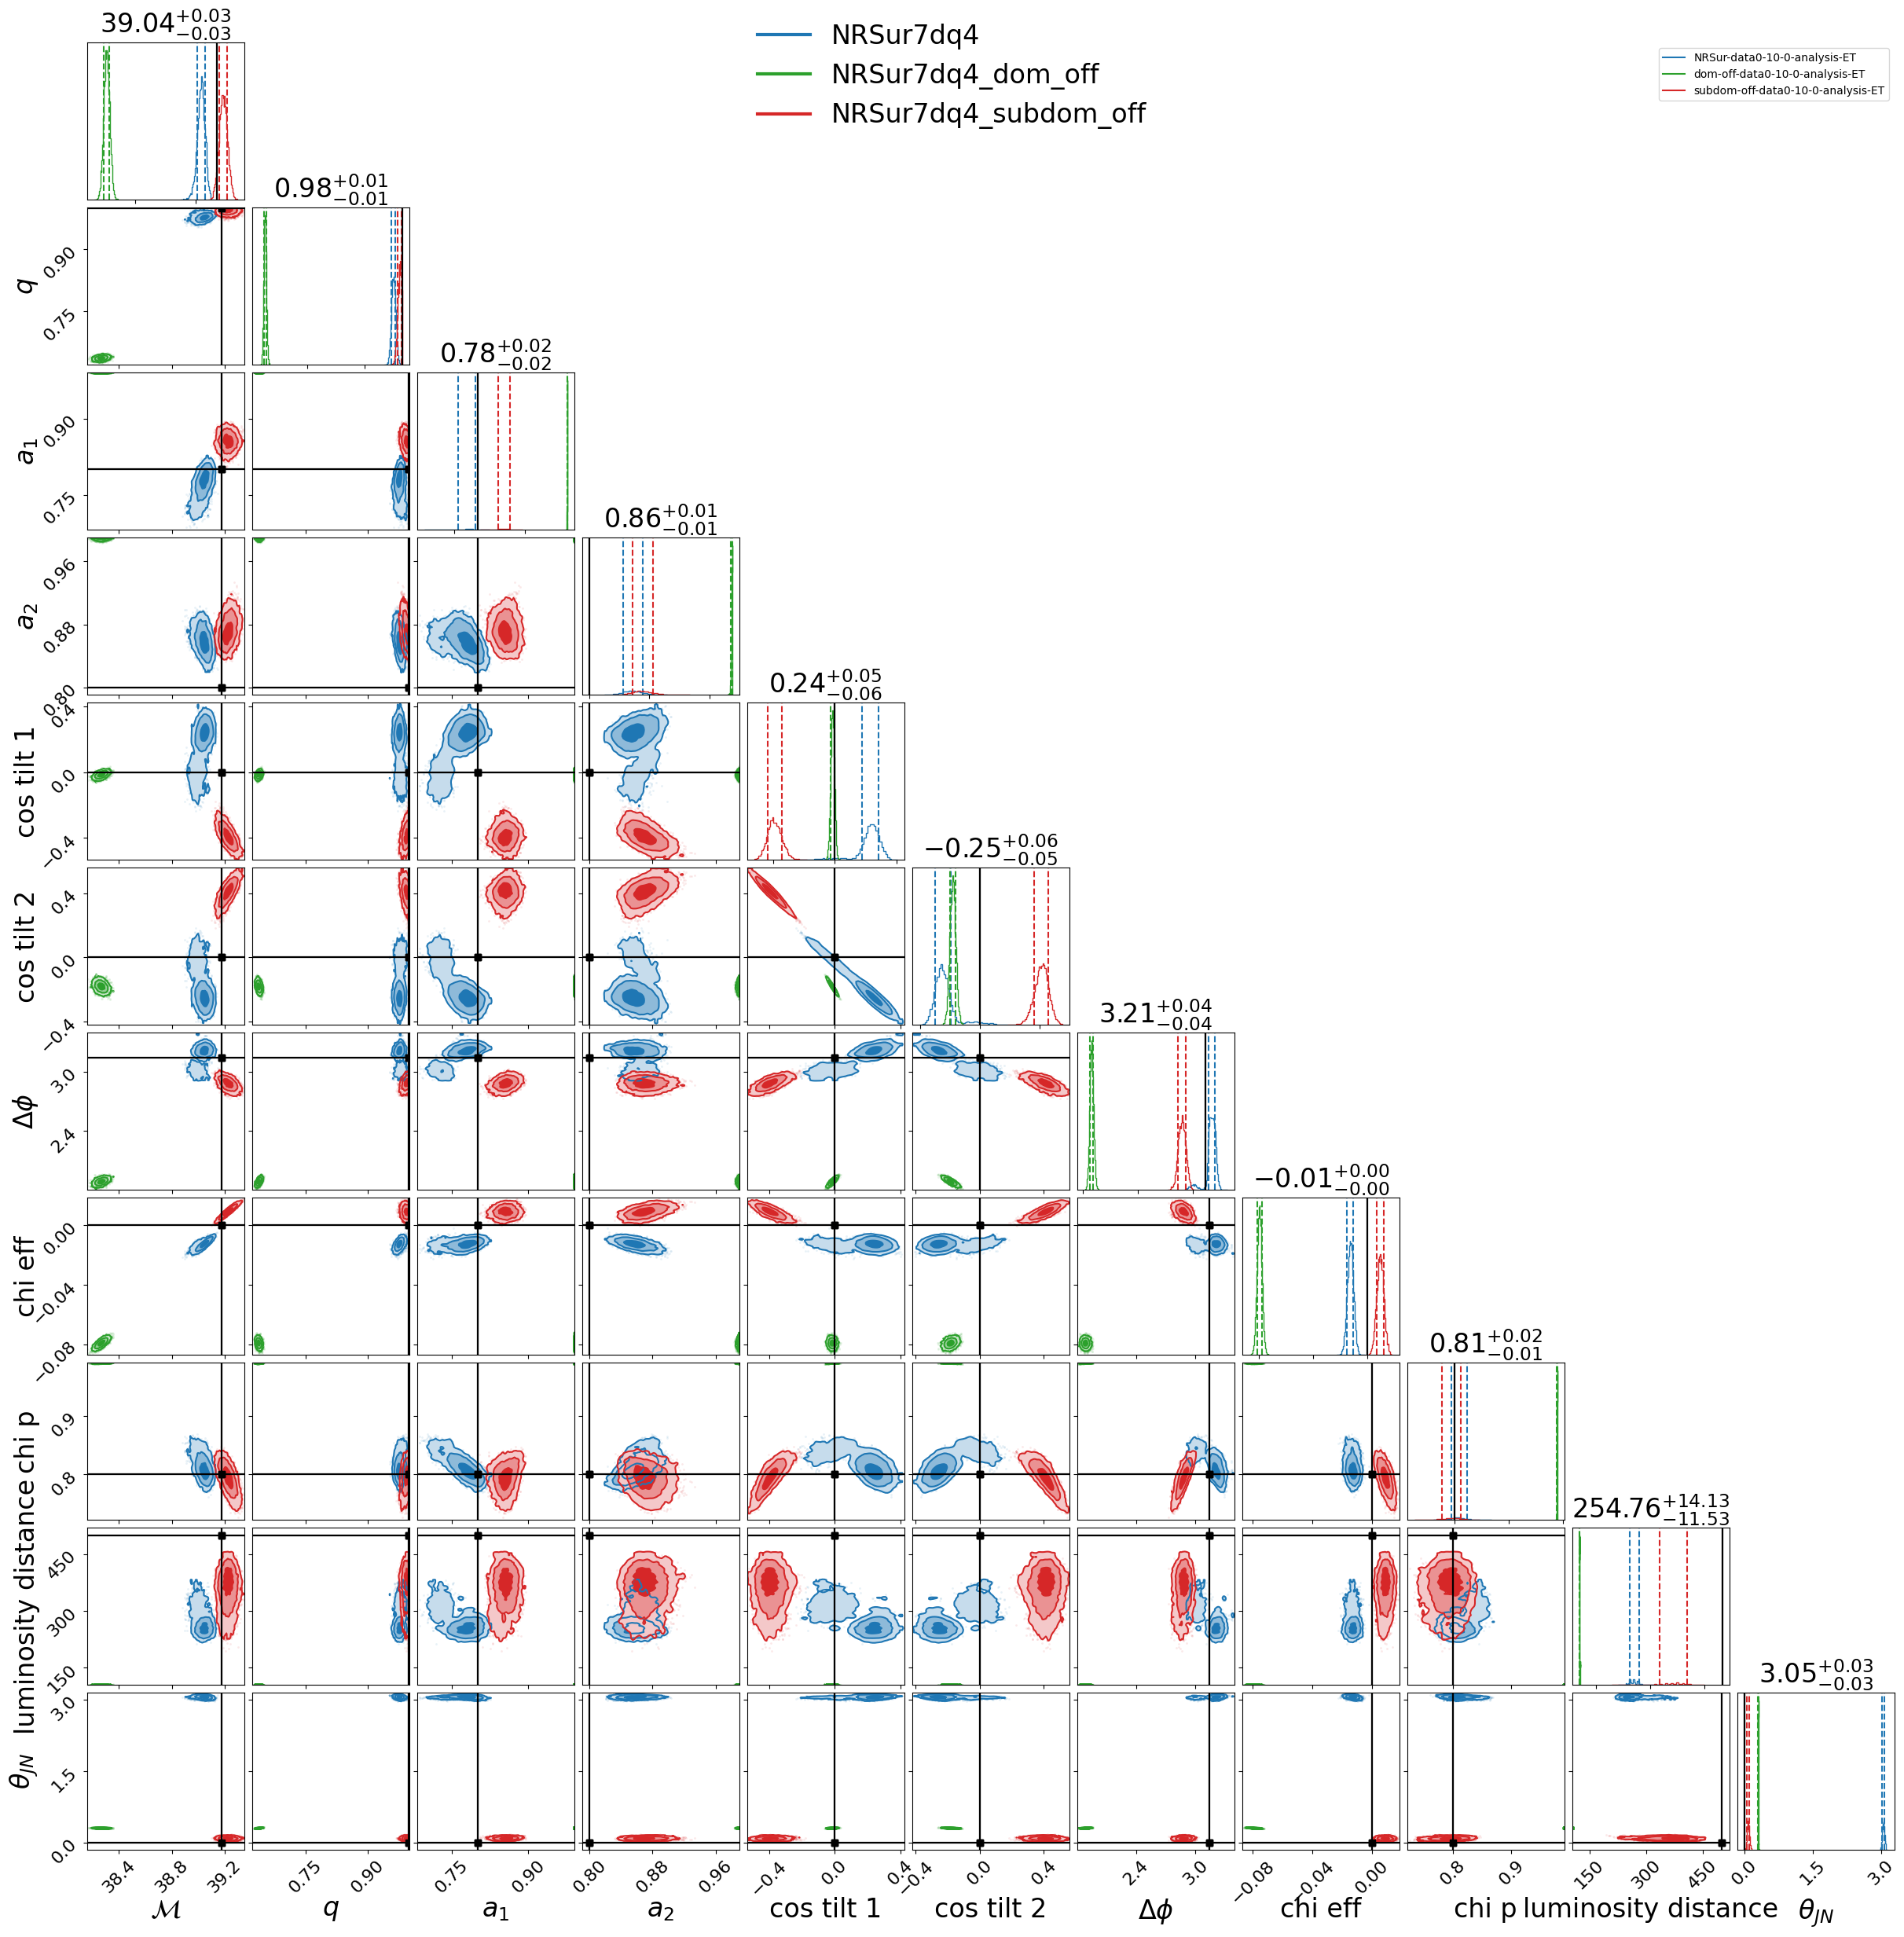

In [7]:
fig = bilby.result.plot_multiple(
    [
        posterior_NRSur7dq4,
        #posterior_NRSur7dq4_sanity,
        posterior_NRSur7dq4_dom_off,
        posterior_NRSur7dq4_subdom_off
    ],
    filename=None, 
    parameters={
        'chirp_mass': truths['chirp_mass'],
        'mass_ratio': truths['mass_ratio'],
        'a_1': truths['a_1'],
        'a_2': truths['a_2'],
        'cos_tilt_1': np.cos(truths['tilt_1']),
        'cos_tilt_2': np.cos(truths['tilt_2']),
        'phi_12': truths['phi_12'],
        'chi_eff': truths['chi_eff'],
        'chi_p': truths['chi_p'],
        'luminosity_distance': truths['luminosity_distance'],
        'theta_jn': truths['theta_jn'],
    },
    colours=['tab:blue', 'tab:green', 'tab:red'],
    smooth=True,
    title_kwargs=dict(fontsize=24),
    label_kwargs=dict(fontsize=24),
    truth_color='black'
)

# tick font size
for ax in fig.axes:
    ax.tick_params(labelsize=16) 


# legend
handles = [
    Line2D([], [], color='tab:blue', lw=3, label='NRSur7dq4'),
    #Line2D([], [], color='tab:orange', lw=3, label='NRSur7dq4_sanity'),
    Line2D([], [], color='tab:green', lw=3, label='NRSur7dq4_dom_off'),
    Line2D([], [], color='tab:red', lw=3, label='NRSur7dq4_subdom_off')]
fig.legend(
    handles=handles,
    fontsize=24,
    loc='upper center',
    frameon=False)

fig.savefig('corner_comparison_run4.pdf', bbox_inches='tight')
plt.show()
